In [16]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import json
import math
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.utils import make_grid

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'models').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
CLASSIFICATION_DIR = PROJECT_ROOT / 'models' / 'classification'
GAN_DIR = PROJECT_ROOT / 'models' / 'gan_study'
GRAPHS_DIR = GAN_DIR / 'graphs'
GAN_DIR.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cpu')

In [17]:
IMAGE_SIZE = 64
CLASSIFIER_IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
MAX_TRAIN_PER_CLASS = 320
MAX_VAL_PER_CLASS = 96
GAN_CLASSES_PREFERRED = ['Battery', 'Mobile', 'PCB', 'light bulbs']
TRIAL_EPOCHS = 15
FINAL_EPOCHS = 40
EVAL_PER_CLASS = 48
SAVE_ARTIFACTS = True

TRIAL_CONFIGS = [
    {
        'trial_name': 'cdgan_hinge_proj_z128_g96_d96',
        'latent_dim': 128,
        'g_channels': 96,
        'd_channels': 96,
        'embed_dim': 64,
        'lr': 2e-4,
        'beta1': 0.0,
    },
    {
        'trial_name': 'cdgan_hinge_proj_z128_g64_d64',
        'latent_dim': 128,
        'g_channels': 64,
        'd_channels': 64,
        'embed_dim': 64,
        'lr': 2e-4,
        'beta1': 0.0,
    },
    {
        'trial_name': 'cdgan_hinge_proj_z96_g64_d64',
        'latent_dim': 96,
        'g_channels': 64,
        'd_channels': 64,
        'embed_dim': 48,
        'lr': 1e-4,
        'beta1': 0.0,
    },
]

def square_pad(image: Image.Image, fill=(114, 114, 114)) -> Image.Image:
    image = image.convert('RGB')
    w, h = image.size
    side = max(w, h)
    pad_left = (side - w) // 2
    pad_top = (side - h) // 2
    pad_right = side - w - pad_left
    pad_bottom = side - h - pad_top
    return ImageOps.expand(image, border=(pad_left, pad_top, pad_right, pad_bottom), fill=fill)

gan_transform = transforms.Compose([
    transforms.Lambda(square_pad),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

classifier_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
classifier_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def prepare_fake_for_classifier(fake_batch: torch.Tensor) -> torch.Tensor:
    x = fake_batch.detach().cpu()
    x = (x + 1.0) / 2.0
    x = x.clamp(0.0, 1.0)
    x = F.interpolate(x, size=(CLASSIFIER_IMAGE_SIZE, CLASSIFIER_IMAGE_SIZE), mode='bilinear', align_corners=False)
    x = (x - classifier_mean) / classifier_std
    return x

def denormalize_gan_tensor(x: torch.Tensor) -> torch.Tensor:
    return ((x.detach().cpu() + 1.0) / 2.0).clamp(0.0, 1.0)

def save_current_figure(path: Path, dpi: int = 160) -> None:
    if SAVE_ARTIFACTS:
        plt.savefig(path, dpi=dpi, bbox_inches='tight')

In [3]:
class ConditionalImageDataset(Dataset):
    def __init__(self, rows: list[tuple[Path, int]], transform):
        self.rows = rows
        self.transform = transform

    def __len__(self) -> int:
        return len(self.rows)

    def __getitem__(self, idx: int):
        path, label = self.rows[idx]
        image = Image.open(path).convert('RGB')
        return self.transform(image), label

def count_split_images(split: str) -> dict[str, int]:
    split_root = DATA_DIR / split
    counts = {}
    if not split_root.exists():
        return counts
    for class_dir in sorted(split_root.iterdir(), key=lambda p: p.name.lower()):
        if class_dir.is_dir():
            counts[class_dir.name] = sum(1 for p in class_dir.rglob('*') if p.is_file())
    return counts

split_counts = {
    'train': count_split_images('train'),
    'val': count_split_images('val'),
    'test': count_split_images('test'),
}

dataset_profile_rows = []
for split_name, mapping in split_counts.items():
    for class_name, count in mapping.items():
        dataset_profile_rows.append({'split': split_name, 'class_name': class_name, 'count': count})
dataset_profile = pd.DataFrame(dataset_profile_rows)

available_classes = set(split_counts['train'].keys())
selected_classes = [cls for cls in GAN_CLASSES_PREFERRED if cls in available_classes]
if len(selected_classes) < 3:
    ranked = sorted(split_counts['train'].items(), key=lambda item: item[1], reverse=True)
    for class_name, _ in ranked:
        if class_name not in selected_classes:
            selected_classes.append(class_name)
        if len(selected_classes) >= 4:
            break

selected_classes = selected_classes[:4]
class_to_idx = {class_name: idx for idx, class_name in enumerate(selected_classes)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

def collect_rows(split: str, class_names: list[str], max_per_class: int) -> list[tuple[Path, int]]:
    split_root = DATA_DIR / split
    rows: list[tuple[Path, int]] = []
    rng = random.Random(SEED + len(split))
    for class_name in class_names:
        class_dir = split_root / class_name
        if not class_dir.exists():
            continue
        files = [p for p in class_dir.rglob('*') if p.is_file()]
        files = sorted(files, key=lambda p: p.name.lower())
        rng.shuffle(files)
        files = files[:max_per_class]
        rows.extend((path, class_to_idx[class_name]) for path in files)
    rng.shuffle(rows)
    return rows

train_rows = collect_rows('train', selected_classes, MAX_TRAIN_PER_CLASS)
val_rows = collect_rows('val', selected_classes, MAX_VAL_PER_CLASS)
if not val_rows:
    val_rows = collect_rows('train', selected_classes, min(80, MAX_VAL_PER_CLASS))

train_dataset = ConditionalImageDataset(train_rows, gan_transform)
val_dataset = ConditionalImageDataset(val_rows, gan_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)

selected_profile = dataset_profile[dataset_profile['class_name'].isin(selected_classes)].copy()
selected_profile.sort_values(['class_name', 'split'])

,split,class_name,count
37,test,Battery,100
1,train,Battery,1160
19,val,Battery,100
44,test,Mobile,100
8,train,Mobile,839
26,val,Mobile,100
47,test,PCB,100
11,train,PCB,841
29,val,PCB,100
41,test,light bulbs,100


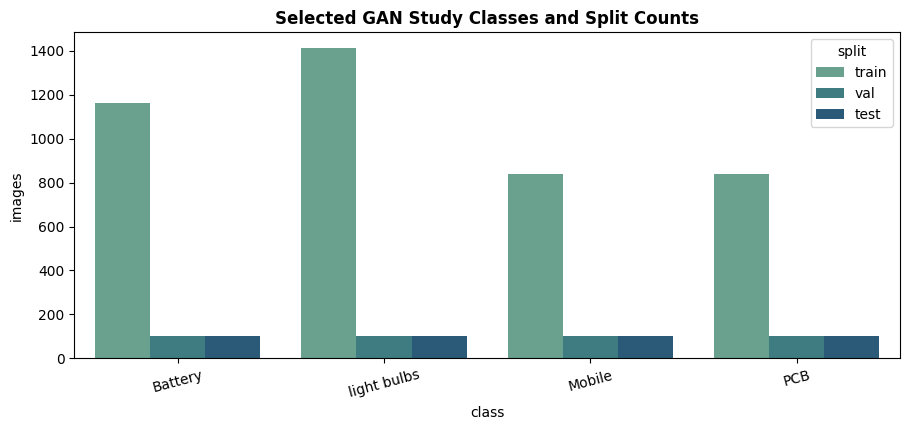

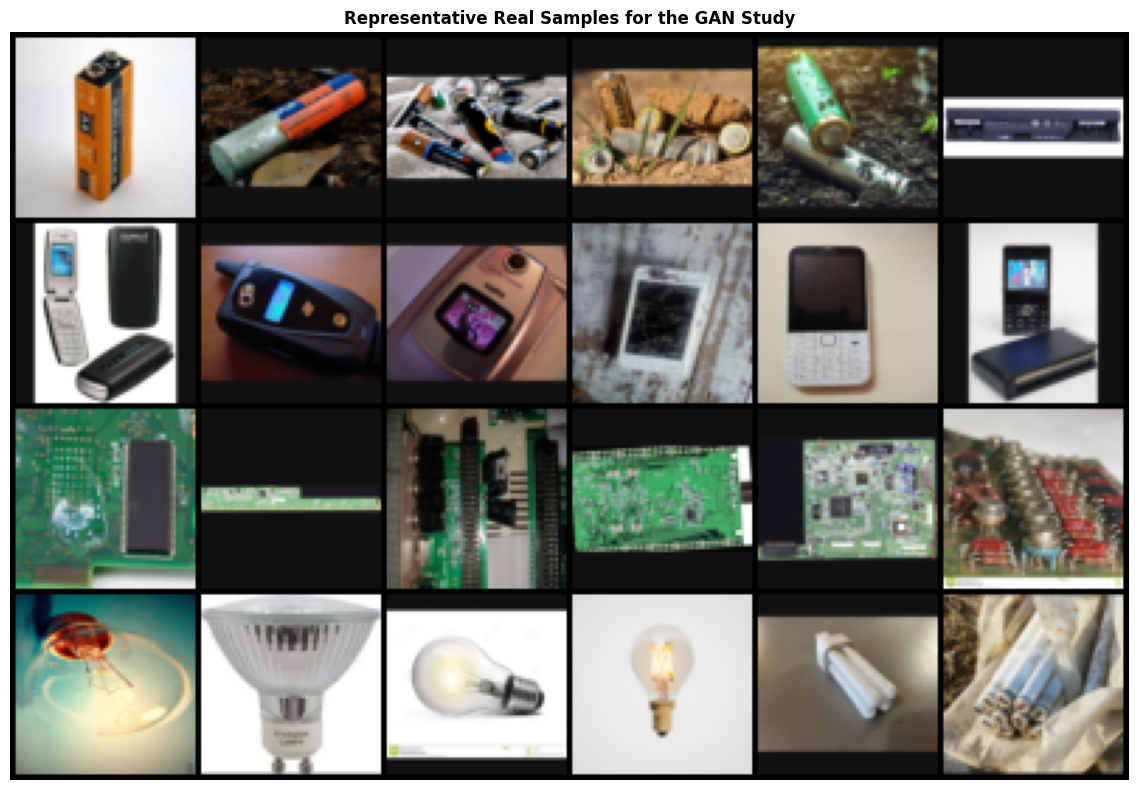

Selected classes: ['Battery', 'Mobile', 'PCB', 'light bulbs']
Training rows: 1280 | Validation rows: 384 | Device: cpu


In [4]:
plt.figure(figsize=(9.2, 4.4))
sns.barplot(data=selected_profile, x='class_name', y='count', hue='split', palette='crest')
plt.title('Selected GAN Study Classes and Split Counts', fontweight='bold')
plt.xlabel('class')
plt.ylabel('images')
plt.xticks(rotation=15)
plt.tight_layout()
save_current_figure(GRAPHS_DIR / 'gan_selected_class_distribution.png')
plt.show()

sample_images = []
for class_name in selected_classes:
    class_idx = class_to_idx[class_name]
    class_examples = [train_dataset[i][0] for i, (_, label) in enumerate(train_rows) if label == class_idx][:6]
    sample_images.extend(class_examples)

grid = make_grid(denormalize_gan_tensor(torch.stack(sample_images)), nrow=6, padding=2)
plt.figure(figsize=(12, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.title('Representative Real Samples for the GAN Study', fontweight='bold')
plt.axis('off')
plt.tight_layout()
save_current_figure(GRAPHS_DIR / 'gan_real_sample_grid.png')
plt.show()

print('Selected classes:', selected_classes)
print('Training rows:', len(train_rows), '| Validation rows:', len(val_rows), '| Device:', DEVICE)

In [24]:
class ConditionalBatchNorm2d(nn.Module):
    def __init__(self, num_features: int, num_classes: int):
        super().__init__()
        self.num_features = num_features
        self.bn = nn.BatchNorm2d(num_features, affine=False)
        self.embed = nn.Embedding(num_classes, num_features * 2)
        self.embed.weight.data[:, :num_features].fill_(1.0)
        self.embed.weight.data[:, num_features:].zero_()

    def forward(self, x: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        x = self.bn(x)
        gamma_beta = self.embed(labels)
        gamma, beta = gamma_beta.chunk(2, dim=1)
        gamma = gamma.view(-1, self.num_features, 1, 1)
        beta = beta.view(-1, self.num_features, 1, 1)
        return gamma * x + beta


class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim: int, num_classes: int, base_channels: int = 64, embed_dim: int = 32):
        super().__init__()
        self.latent_dim = latent_dim
        self.label_embed = nn.Embedding(num_classes, embed_dim)
        self.project = nn.Sequential(
            nn.Linear(latent_dim + embed_dim, base_channels * 8 * 4 * 4),
            nn.BatchNorm1d(base_channels * 8 * 4 * 4),
            nn.ReLU(inplace=True),
        )
        self.up1 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 4, 2, 1, bias=False)
        self.cbn1 = ConditionalBatchNorm2d(base_channels * 4, num_classes)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, 2, 1, bias=False)
        self.cbn2 = ConditionalBatchNorm2d(base_channels * 2, num_classes)
        self.up3 = nn.ConvTranspose2d(base_channels * 2, base_channels, 4, 2, 1, bias=False)
        self.cbn3 = ConditionalBatchNorm2d(base_channels, num_classes)
        self.up4 = nn.ConvTranspose2d(base_channels, 3, 4, 2, 1, bias=False)
        self.act = nn.Tanh()

    def forward(self, noise: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        label_vec = self.label_embed(labels)
        x = torch.cat([noise, label_vec], dim=1)
        x = self.project(x)
        x = x.view(x.size(0), -1, 4, 4)
        x = self.cbn1(self.up1(x), labels)
        x = F.relu(x, inplace=True)
        x = self.cbn2(self.up2(x), labels)
        x = F.relu(x, inplace=True)
        x = self.cbn3(self.up3(x), labels)
        x = F.relu(x, inplace=True)
        x = self.up4(x)
        return self.act(x)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes: int, base_channels: int = 64):
        super().__init__()
        self.features = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(3, base_channels, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.utils.spectral_norm(nn.Conv2d(base_channels * 4, base_channels * 8, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classifier = nn.utils.spectral_norm(nn.Linear(base_channels * 8 * 4 * 4, 1))
        self.label_embed = nn.Embedding(num_classes, base_channels * 8 * 4 * 4)

    def forward(self, images: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        x = self.features(images)
        x = x.view(x.size(0), -1)
        out = self.classifier(x)
        proj = (self.label_embed(labels) * x).sum(dim=1, keepdim=True)
        return (out + proj).squeeze(1)


def weights_init(module: nn.Module) -> None:
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        if getattr(module, 'weight', None) is not None:
            nn.init.normal_(module.weight, 0.0, 0.02)
        if getattr(module, 'bias', None) is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, (nn.BatchNorm2d, nn.BatchNorm1d)):
        if getattr(module, 'weight', None) is not None:
            nn.init.normal_(module.weight, 1.0, 0.02)
        if getattr(module, 'bias', None) is not None:
            nn.init.zeros_(module.bias)


def sample_noise(batch_size: int, latent_dim: int, device: torch.device) -> torch.Tensor:
    return torch.randn(batch_size, latent_dim, device=device)


def build_fixed_sampling_inputs(latent_dim: int, class_count: int, n_per_class: int = 6):
    labels = []
    for class_idx in range(class_count):
        labels.extend([class_idx] * n_per_class)
    labels = torch.tensor(labels, dtype=torch.long)
    noise = torch.randn(len(labels), latent_dim)
    return noise, labels

In [19]:
best_info = json.loads((CLASSIFICATION_DIR / 'best_model.json').read_text(encoding='utf-8'))
best_arch = best_info['best_arch']
best_checkpoint_path = PROJECT_ROOT / best_info['checkpoint']

from training.image_preprocessing import SquarePadResize, IMAGENET_MEAN, IMAGENET_STD, LETTERBOX_FILL

checkpoint_obj = torch.load(best_checkpoint_path, map_location=DEVICE)

def load_trained_class_names(arch: str) -> tuple[list[str] | None, str | None]:
    candidates = [
        CLASSIFICATION_DIR / arch / 'results.json',
        CLASSIFICATION_DIR / 'benchmark_summary.json',
    ]
    for path in candidates:
        if not path.exists():
            continue
        try:
            payload = json.loads(path.read_text(encoding='utf-8'))
        except (OSError, json.JSONDecodeError):
            continue
        class_names = payload.get('class_names')
        if isinstance(class_names, list) and all(isinstance(x, str) for x in class_names):
            rel_path = str(path.relative_to(PROJECT_ROOT)).replace('\\', '/')
            return class_names, rel_path
    return None, None

trained_class_names = None
class_names_source = None
if isinstance(checkpoint_obj, dict):
    ckpt_names = checkpoint_obj.get('class_names')
    if isinstance(ckpt_names, list) and all(isinstance(x, str) for x in ckpt_names):
        trained_class_names = ckpt_names
        class_names_source = 'checkpoint'
if trained_class_names is None:
    trained_class_names, class_names_source = load_trained_class_names(best_arch)

if trained_class_names:
    full_class_names = trained_class_names
else:
    # ImageFolder sorts class names case-sensitively; match that ordering.
    full_class_names = sorted([p.name for p in (DATA_DIR / 'train').iterdir() if p.is_dir()])
    class_names_source = 'data_dir'

full_class_to_idx = {class_name: idx for idx, class_name in enumerate(full_class_names)}
missing_classes = [cls for cls in selected_classes if cls not in full_class_to_idx]
if missing_classes:
    raise ValueError(f'Missing selected classes in classifier mapping: {missing_classes}')

def build_classifier_for_inference(arch: str, num_classes: int) -> nn.Module:
    if arch == 'resnet18':
        model = models.resnet18(weights=None)
        in_dim = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        return model
    if arch == 'resnet50':
        model = models.resnet50(weights=None)
        in_dim = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        return model
    if arch == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=None)
        in_dim = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        return model
    if arch == 'efficientnet_b3':
        model = models.efficientnet_b3(weights=None)
        in_dim = model.classifier[-1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        return model
    if arch == 'convnext_tiny':
        model = models.convnext_tiny(weights=None)
        in_dim = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_dim, num_classes)
        return model
    if arch == 'swin_tiny':
        model = models.swin_t(weights=None)
        in_dim = model.head.in_features
        model.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_dim, num_classes))
        return model
    if arch == 'vit_b16':
        model = models.vit_b_16(weights=None)
        in_dim = model.heads.head.in_features
        model.heads.head = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        return model
    raise ValueError(f'Unsupported classifier architecture: {arch}')

classifier_model = build_classifier_for_inference(best_arch, len(full_class_names)).to(DEVICE)
if isinstance(checkpoint_obj, dict) and 'model_state_dict' in checkpoint_obj:
    state_dict = checkpoint_obj['model_state_dict']
elif isinstance(checkpoint_obj, dict) and 'state_dict' in checkpoint_obj:
    state_dict = checkpoint_obj['state_dict']
else:
    state_dict = checkpoint_obj
classifier_model.load_state_dict(state_dict)
classifier_model.eval()

classifier_eval_transform = transforms.Compose([
    SquarePadResize(CLASSIFIER_IMAGE_SIZE, fill=LETTERBOX_FILL),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

real_eval_images = []
real_eval_targets = []
for path, local_label in val_rows:
    class_name = idx_to_class[local_label]
    real_eval_images.append(classifier_eval_transform(Image.open(path).convert('RGB')))
    real_eval_targets.append(full_class_to_idx[class_name])

real_eval_images = torch.stack(real_eval_images)
real_eval_targets = torch.tensor(real_eval_targets, dtype=torch.long)

with torch.no_grad():
    real_logits = []
    for start in range(0, len(real_eval_images), 64):
        batch = real_eval_images[start:start + 64].to(DEVICE)
        logits = classifier_model(batch)
        real_logits.append(logits.detach().cpu())
    real_logits = torch.cat(real_logits, dim=0).numpy()

real_targets_np = real_eval_targets.numpy()
real_preds = real_logits.argmax(axis=1)
real_acc = float((real_preds == real_targets_np).mean()) if len(real_preds) else 0.0

per_class_acc = {}
for class_name in selected_classes:
    global_idx = full_class_to_idx[class_name]
    mask = real_targets_np == global_idx
    if mask.any():
        per_class_acc[class_name] = float((real_preds[mask] == global_idx).mean())
    else:
        per_class_acc[class_name] = 0.0

top_pred_labels = [(full_class_names[idx], count) for idx, count in Counter(real_preds).most_common(5)]

print('Best classifier for GAN evaluation:', best_arch)
print(f'Class names source: {class_names_source}')
print('Real evaluation pool shape:', real_logits.shape)
print(f'Classifier sanity check (selected real images): {real_acc:.3f}')
print('Top predicted classes:', top_pred_labels)
print('Per-class accuracy (selected):', per_class_acc)

Best classifier for GAN evaluation: convnext_tiny
Class names source: models/classification/convnext_tiny/results.json
Real evaluation pool shape: (384, 18)
Classifier sanity check (selected real images): 0.979
Top predicted classes: [('PCB', 96), ('Mobile', 95), ('light bulbs', 94), ('Battery', 91), ('Passive-Component', 3)]
Per-class accuracy (selected): {'Battery': 0.9479166666666666, 'Mobile': 0.9895833333333334, 'PCB': 1.0, 'light bulbs': 0.9791666666666666}


In [25]:
def matrix_sqrt_psd(matrix: np.ndarray) -> np.ndarray:
    matrix = 0.5 * (matrix + matrix.T)
    eigvals, eigvecs = np.linalg.eigh(matrix)
    eigvals = np.clip(eigvals, 0.0, None)
    return (eigvecs * np.sqrt(eigvals)) @ eigvecs.T

def frechet_distance_from_features(real_features: np.ndarray, fake_features: np.ndarray) -> float:
    mu_r = real_features.mean(axis=0)
    mu_f = fake_features.mean(axis=0)
    sigma_r = np.cov(real_features, rowvar=False)
    sigma_f = np.cov(fake_features, rowvar=False)
    diff = mu_r - mu_f
    sqrt_sigma_r = matrix_sqrt_psd(sigma_r)
    middle = sqrt_sigma_r @ sigma_f @ sqrt_sigma_r
    covmean = matrix_sqrt_psd(middle)
    fid_like = float(diff @ diff + np.trace(sigma_r) + np.trace(sigma_f) - 2.0 * np.trace(covmean))
    return max(fid_like, 0.0)

def logits_diversity_score(fake_logits: np.ndarray) -> float:
    if len(fake_logits) < 2:
        return 0.0
    sample = fake_logits[: min(180, len(fake_logits))]
    distances = pairwise_distances(sample, metric='euclidean')
    tri_upper = distances[np.triu_indices_from(distances, k=1)]
    return float(tri_upper.mean())

def generate_class_conditioned_batch(generator: nn.Module, class_idx: int, latent_dim: int, n: int) -> torch.Tensor:
    labels = torch.full((n,), class_idx, dtype=torch.long, device=DEVICE)
    noise = sample_noise(n, latent_dim, DEVICE)
    with torch.no_grad():
        fake = generator(noise, labels)
    return fake

def evaluate_generator(generator: nn.Module, latent_dim: int, eval_per_class: int = EVAL_PER_CLASS) -> dict:
    generator.eval()
    all_fake_logits = []
    all_target_probs = []
    all_target_hits = []
    generated_label_ids = []
    preview_images = []

    with torch.no_grad():
        for local_idx, class_name in idx_to_class.items():
            fake = generate_class_conditioned_batch(generator, local_idx, latent_dim, eval_per_class)
            preview_images.append(fake[: min(6, eval_per_class)].detach().cpu())
            classifier_input = prepare_fake_for_classifier(fake).to(DEVICE)
            logits = classifier_model(classifier_input)
            probs = torch.softmax(logits, dim=1)
            global_target_idx = full_class_to_idx[class_name]
            preds = probs.argmax(dim=1)
            target_probs = probs[:, global_target_idx]

            all_fake_logits.append(logits.detach().cpu())
            all_target_probs.append(target_probs.detach().cpu())
            all_target_hits.append((preds == global_target_idx).float().detach().cpu())
            generated_label_ids.extend([global_target_idx] * eval_per_class)

    fake_logits = torch.cat(all_fake_logits, dim=0).numpy()
    target_probs = torch.cat(all_target_probs, dim=0).numpy()
    target_hits = torch.cat(all_target_hits, dim=0).numpy()

    feature_fd = frechet_distance_from_features(real_logits, fake_logits)
    diversity = logits_diversity_score(fake_logits)
    per_class_conf = {}
    generated_label_ids = np.array(generated_label_ids)
    for class_name in selected_classes:
        global_idx = full_class_to_idx[class_name]
        mask = generated_label_ids == global_idx
        per_class_conf[class_name] = float(target_probs[mask].mean())

    preview_tensor = torch.cat(preview_images, dim=0) if preview_images else None
    preview_grid = make_grid(denormalize_gan_tensor(preview_tensor), nrow=6, padding=2) if preview_tensor is not None else None
    return {
        'classifier_target_accuracy': float(target_hits.mean()),
        'mean_target_probability': float(target_probs.mean()),
        'frechet_logit_distance': float(feature_fd),
        'diversity_score': float(diversity),
        'per_class_target_probability': per_class_conf,
        'preview_grid': preview_grid,
        'fake_logits': fake_logits,
    }

def train_gan_trial(config: dict, epochs: int, keep_model: bool = False):
    latent_dim = int(config['latent_dim'])
    generator = ConditionalGenerator(latent_dim, len(selected_classes), base_channels=int(config['g_channels']), embed_dim=int(config['embed_dim'])).to(DEVICE)
    discriminator = ConditionalDiscriminator(len(selected_classes), base_channels=int(config['d_channels'])).to(DEVICE)
    generator.apply(weights_init)
    discriminator.apply(weights_init)

    opt_g = torch.optim.Adam(generator.parameters(), lr=float(config['lr']), betas=(float(config['beta1']), 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=float(config['lr']), betas=(float(config['beta1']), 0.999))
    fixed_noise, fixed_labels = build_fixed_sampling_inputs(latent_dim, len(selected_classes), n_per_class=6)
    fixed_noise = fixed_noise.to(DEVICE)
    fixed_labels = fixed_labels.to(DEVICE)

    history = []
    for epoch in range(1, epochs + 1):
        generator.train()
        discriminator.train()
        d_running = 0.0
        g_running = 0.0
        steps = 0

        for real_images, labels in train_loader:
            real_images = real_images.to(DEVICE)
            labels = labels.to(DEVICE)
            batch_size = real_images.size(0)

            opt_d.zero_grad(set_to_none=True)
            real_logits_batch = discriminator(real_images, labels)
            noise = sample_noise(batch_size, latent_dim, DEVICE)
            fake_images = generator(noise, labels)
            fake_logits_batch = discriminator(fake_images.detach(), labels)
            d_loss = F.relu(1.0 - real_logits_batch).mean() + F.relu(1.0 + fake_logits_batch).mean()
            d_loss.backward()
            opt_d.step()

            opt_g.zero_grad(set_to_none=True)
            fake_logits_for_g = discriminator(fake_images, labels)
            g_loss = -fake_logits_for_g.mean()
            g_loss.backward()
            opt_g.step()

            d_running += float(d_loss.item())
            g_running += float(g_loss.item())
            steps += 1

        metrics = evaluate_generator(generator, latent_dim, eval_per_class=EVAL_PER_CLASS)
        history.append({
            'epoch': epoch,
            'd_loss': d_running / max(steps, 1),
            'g_loss': g_running / max(steps, 1),
            'classifier_target_accuracy': metrics['classifier_target_accuracy'],
            'mean_target_probability': metrics['mean_target_probability'],
            'frechet_logit_distance': metrics['frechet_logit_distance'],
            'diversity_score': metrics['diversity_score'],
        })

    final_metrics = evaluate_generator(generator, latent_dim, eval_per_class=EVAL_PER_CLASS)
    payload = {
        'config': config,
        'history': history,
        'final_metrics': {k: v for k, v in final_metrics.items() if k not in {'preview_grid', 'fake_logits'}},
        'preview_grid': final_metrics['preview_grid'],
        'fake_logits': final_metrics['fake_logits'],
    }
    if keep_model:
        payload['generator'] = generator
        payload['discriminator'] = discriminator
    return payload

In [26]:
trial_payloads = []
trial_histories = {}

for cfg in TRIAL_CONFIGS:
    print(f"Running trial: {cfg['trial_name']}")
    payload = train_gan_trial(cfg, epochs=TRIAL_EPOCHS, keep_model=False)
    trial_payloads.append(payload)
    trial_histories[cfg['trial_name']] = payload['history']

trial_rows = []
for payload in trial_payloads:
    cfg = payload['config']
    metrics = payload['final_metrics']
    trial_rows.append({
        'trial_name': cfg['trial_name'],
        'latent_dim': cfg['latent_dim'],
        'g_channels': cfg['g_channels'],
        'd_channels': cfg['d_channels'],
        'embed_dim': cfg['embed_dim'],
        'lr': cfg['lr'],
        'beta1': cfg['beta1'],
        'classifier_target_accuracy': metrics['classifier_target_accuracy'],
        'mean_target_probability': metrics['mean_target_probability'],
        'frechet_logit_distance': metrics['frechet_logit_distance'],
        'diversity_score': metrics['diversity_score'],
    })

trial_df = pd.DataFrame(trial_rows)
for column in ['classifier_target_accuracy', 'mean_target_probability', 'diversity_score']:
    trial_df[f'norm_{column}'] = (trial_df[column] - trial_df[column].min()) / (trial_df[column].max() - trial_df[column].min() + 1e-8)
trial_df['norm_frechet'] = (trial_df['frechet_logit_distance'] - trial_df['frechet_logit_distance'].min()) / (trial_df['frechet_logit_distance'].max() - trial_df['frechet_logit_distance'].min() + 1e-8)
trial_df['composite_score'] = (
    0.40 * trial_df['norm_classifier_target_accuracy'] +
    0.25 * trial_df['norm_mean_target_probability'] +
    0.20 * (1.0 - trial_df['norm_frechet']) +
    0.15 * trial_df['norm_diversity_score']
 )
trial_df = trial_df.sort_values('composite_score', ascending=False).reset_index(drop=True)

if SAVE_ARTIFACTS:
    (GAN_DIR / 'gan_trial_results.json').write_text(
        json.dumps({'trials': trial_df.to_dict(orient='records')}, indent=2),
        encoding='utf-8',
    )

trial_df

Running trial: cdgan_hinge_proj_z128_g96_d96
Running trial: cdgan_hinge_proj_z128_g64_d64
Running trial: cdgan_hinge_proj_z96_g64_d64


,trial_name,latent_dim,g_channels,d_channels,embed_dim,lr,beta1,classifier_target_accuracy,mean_target_probability,frechet_logit_distance,diversity_score,norm_classifier_target_accuracy,norm_mean_target_probability,norm_diversity_score,norm_frechet,composite_score
0,cdgan_hinge_proj_z128_g96_d96,128,96,96,64,0.0002,0.0,0.0,0.031189,57.993008,2.110887,0.0,0.999999,0.000000,0.000000,0.450000
1,cdgan_hinge_proj_z96_g64_d64,96,64,64,48,0.0001,0.0,0.0,0.021116,60.976116,2.281722,0.0,0.209563,0.247218,0.576362,0.174201
2,cdgan_hinge_proj_z128_g64_d64,128,64,64,64,0.0002,0.0,0.0,0.018446,63.168758,2.801919,0.0,0.000000,1.000000,1.000000,0.150000


C:\Users\harsh\AppData\Local\Temp\ipykernel_15308\2495731391.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=frame, x=column, y='trial_name', ax=ax, palette='viridis')
C:\Users\harsh\AppData\Local\Temp\ipykernel_15308\2495731391.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=frame, x=column, y='trial_name', ax=ax, palette='viridis')
C:\Users\harsh\AppData\Local\Temp\ipykernel_15308\2495731391.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=frame, x=column, y='trial_name', ax=ax, palette='viridis')
C:\Users\hars

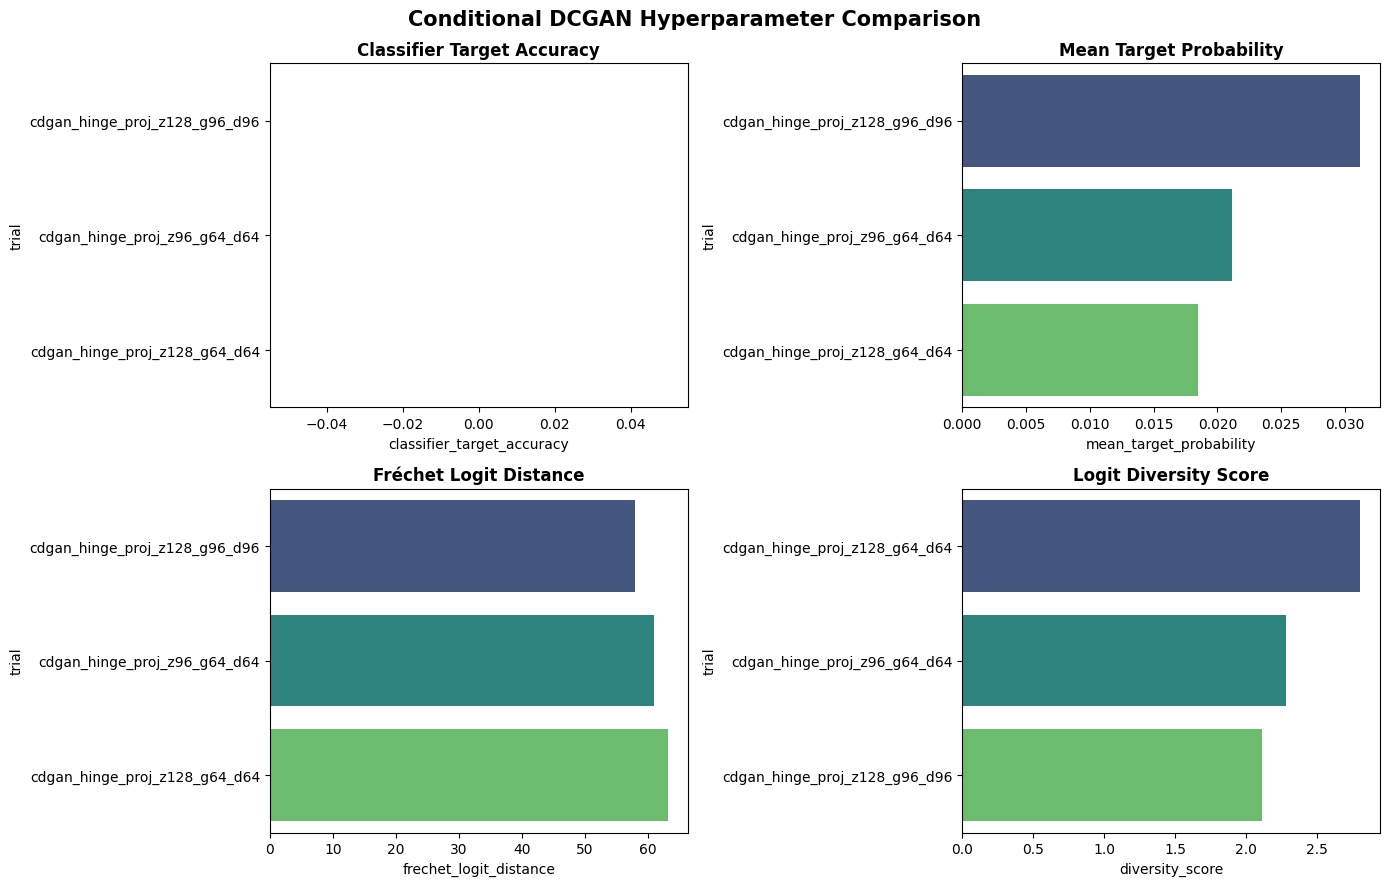

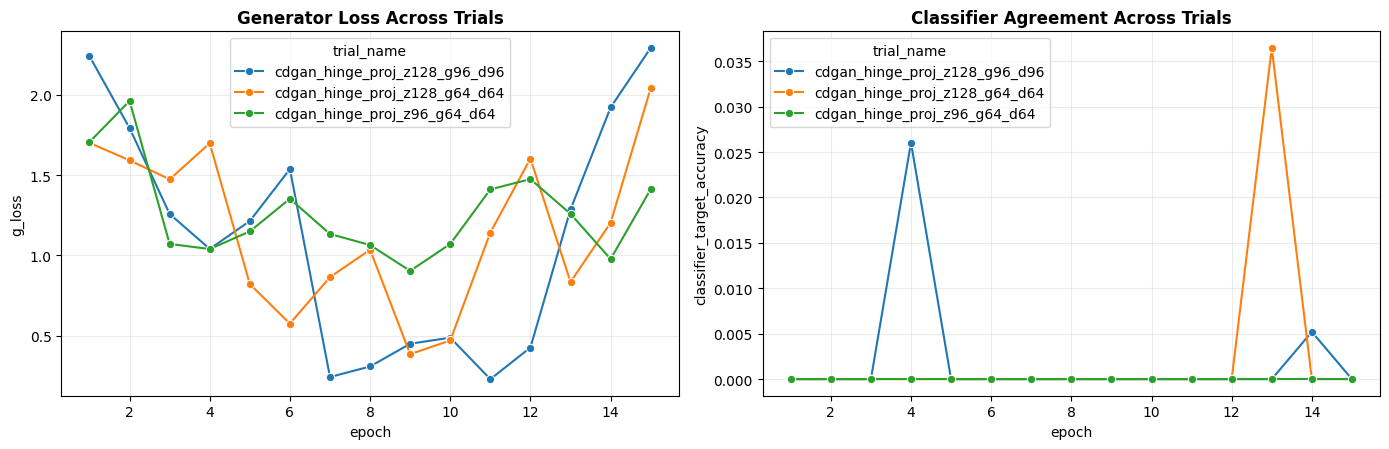

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_specs = [
    ('classifier_target_accuracy', 'Classifier Target Accuracy', False),
    ('mean_target_probability', 'Mean Target Probability', False),
    ('frechet_logit_distance', 'Fr\u00e9chet Logit Distance', True),
    ('diversity_score', 'Logit Diversity Score', False),
]

for ax, (column, title, ascending) in zip(axes.ravel(), plot_specs):
    frame = trial_df.sort_values(column, ascending=ascending)
    sns.barplot(data=frame, x=column, y='trial_name', ax=ax, palette='viridis')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(column)
    ax.set_ylabel('trial')

fig.suptitle('Conditional DCGAN Hyperparameter Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
save_current_figure(GRAPHS_DIR / 'gan_trial_comparison.png')
plt.show()

history_rows = []
for trial_name, history in trial_histories.items():
    for row in history:
        row_copy = dict(row)
        row_copy['trial_name'] = trial_name
        history_rows.append(row_copy)
history_df = pd.DataFrame(history_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.lineplot(data=history_df, x='epoch', y='g_loss', hue='trial_name', marker='o', ax=axes[0])
axes[0].set_title('Generator Loss Across Trials', fontweight='bold')
axes[0].grid(alpha=0.25)
sns.lineplot(data=history_df, x='epoch', y='classifier_target_accuracy', hue='trial_name', marker='o', ax=axes[1])
axes[1].set_title('Classifier Agreement Across Trials', fontweight='bold')
axes[1].grid(alpha=0.25)
plt.tight_layout()
save_current_figure(GRAPHS_DIR / 'gan_trial_learning_curves.png')
plt.show()

In [27]:
if trial_df.empty:
    raise ValueError('trial_df is empty. Re-run the trial training cell first.')

best_trial_name = trial_df.iloc[0]['trial_name']
best_config = next((cfg for cfg in TRIAL_CONFIGS if cfg['trial_name'] == best_trial_name), None)
if best_config is None:
    trial_row = trial_df.iloc[0]
    embed_dim = int(trial_row['embed_dim']) if 'embed_dim' in trial_row else int(TRIAL_CONFIGS[0]['embed_dim'])
    best_config = {
        'trial_name': best_trial_name,
        'latent_dim': int(trial_row['latent_dim']),
        'g_channels': int(trial_row['g_channels']),
        'd_channels': int(trial_row['d_channels']),
        'embed_dim': embed_dim,
        'lr': float(trial_row['lr']),
        'beta1': float(trial_row['beta1']),
    }
    print('Warning: best trial not found in TRIAL_CONFIGS; reconstructed config from trial_df.')

print('Best trial selected for deeper analysis:', best_trial_name)

best_payload = train_gan_trial(best_config, epochs=FINAL_EPOCHS, keep_model=True)
best_generator = best_payload['generator']
best_history = pd.DataFrame(best_payload['history'])
best_metrics = best_payload['final_metrics']

best_summary = {
    'selected_classes': selected_classes,
    'best_trial_name': best_trial_name,
    'best_config': best_config,
    'trial_epochs': TRIAL_EPOCHS,
    'final_epochs': FINAL_EPOCHS,
    'final_metrics': best_metrics,
}

if SAVE_ARTIFACTS:
    (GAN_DIR / 'best_gan_config.json').write_text(json.dumps(best_summary, indent=2), encoding='utf-8')

best_summary

Best trial selected for deeper analysis: cdgan_hinge_proj_z128_g96_d96


{'selected_classes': ['Battery', 'Mobile', 'PCB', 'light bulbs'],
 'best_trial_name': 'cdgan_hinge_proj_z128_g96_d96',
 'best_config': {'trial_name': 'cdgan_hinge_proj_z128_g96_d96',
  'latent_dim': 128,
  'g_channels': 96,
  'd_channels': 96,
  'embed_dim': 64,
  'lr': 0.0002,
  'beta1': 0.0},
 'trial_epochs': 15,
 'final_epochs': 40,
 'final_metrics': {'classifier_target_accuracy': 0.0,
  'mean_target_probability': 0.028419548645615578,
  'frechet_logit_distance': 58.75554171336801,
  'diversity_score': 2.509791612625122,
  'per_class_target_probability': {'Battery': 0.05588604882359505,
   'Mobile': 0.032403137534856796,
   'PCB': 0.018535597249865532,
   'light bulbs': 0.006853416562080383}}}

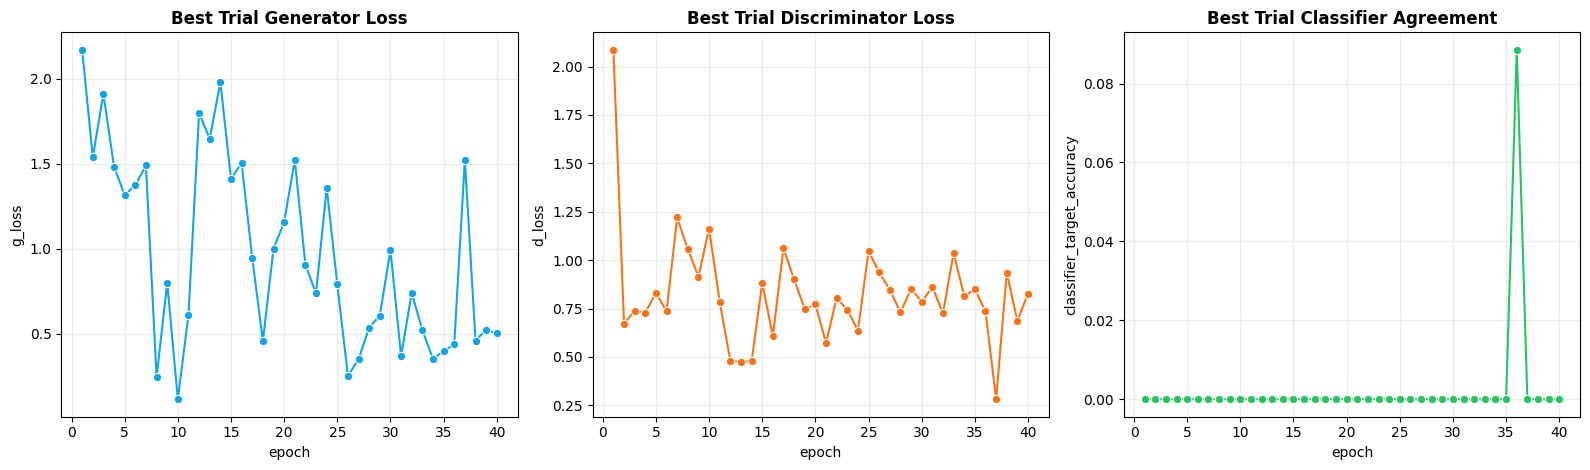

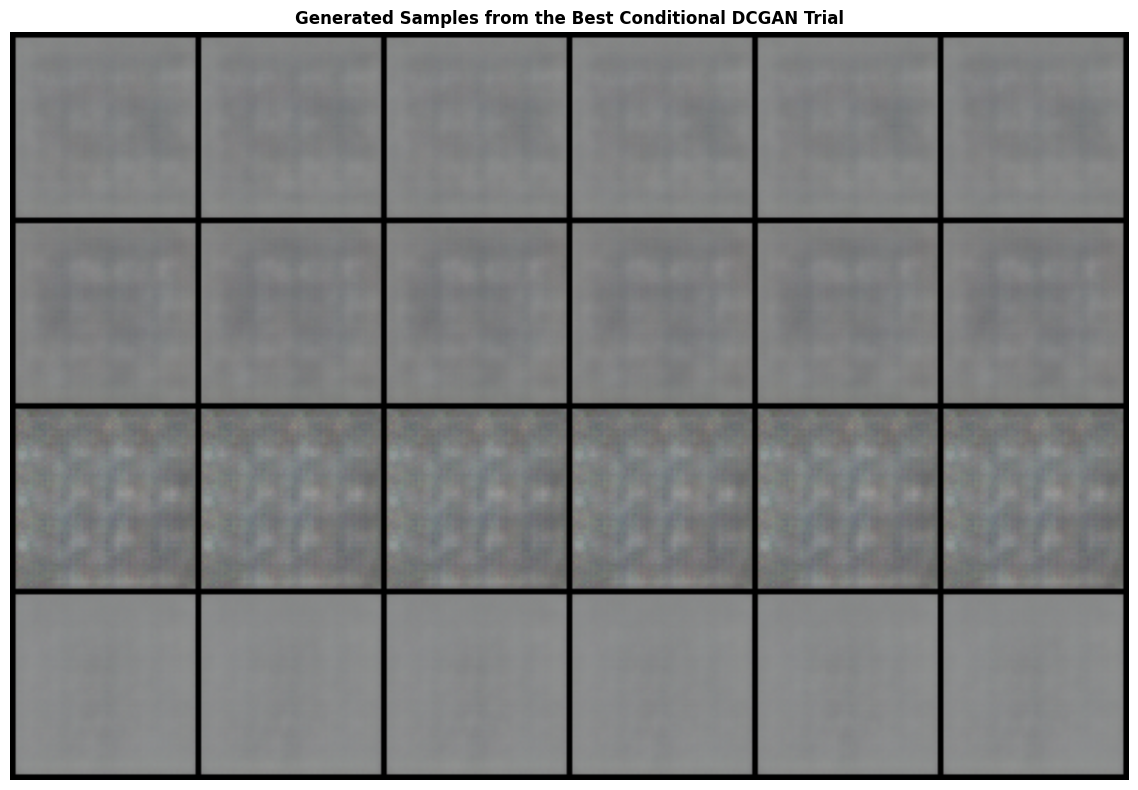

C:\Users\harsh\AppData\Local\Temp\ipykernel_15308\1273187770.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=per_class_conf.index, y=per_class_conf.values, palette='mako')


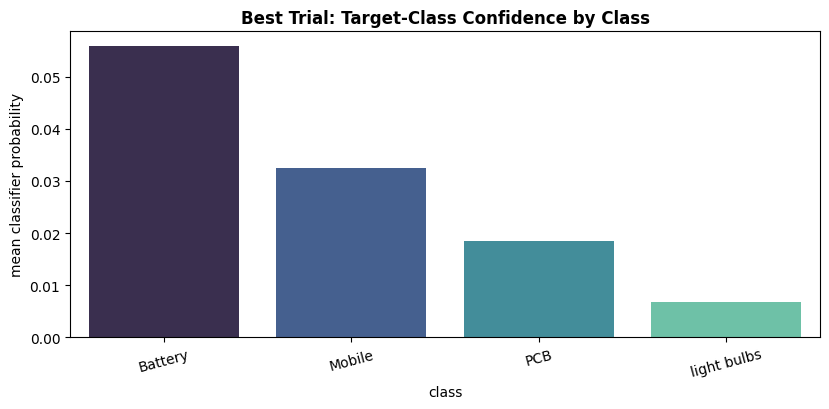

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sns.lineplot(data=best_history, x='epoch', y='g_loss', marker='o', ax=axes[0], color='#0ea5e9')
axes[0].set_title('Best Trial Generator Loss', fontweight='bold')
axes[0].grid(alpha=0.25)
sns.lineplot(data=best_history, x='epoch', y='d_loss', marker='o', ax=axes[1], color='#f97316')
axes[1].set_title('Best Trial Discriminator Loss', fontweight='bold')
axes[1].grid(alpha=0.25)
sns.lineplot(data=best_history, x='epoch', y='classifier_target_accuracy', marker='o', ax=axes[2], color='#22c55e')
axes[2].set_title('Best Trial Classifier Agreement', fontweight='bold')
axes[2].grid(alpha=0.25)
plt.tight_layout()
save_current_figure(GRAPHS_DIR / 'gan_best_training_curves.png')
plt.show()

preview_grid = best_payload['preview_grid']
plt.figure(figsize=(12, 8))
plt.imshow(preview_grid.permute(1, 2, 0))
plt.title('Generated Samples from the Best Conditional DCGAN Trial', fontweight='bold')
plt.axis('off')
plt.tight_layout()
save_current_figure(GRAPHS_DIR / 'gan_best_generated_grid.png')
plt.show()

per_class_conf = pd.Series(best_metrics['per_class_target_probability']).sort_values(ascending=False)
plt.figure(figsize=(8.4, 4.2))
sns.barplot(x=per_class_conf.index, y=per_class_conf.values, palette='mako')
plt.title('Best Trial: Target-Class Confidence by Class', fontweight='bold')
plt.ylabel('mean classifier probability')
plt.xlabel('class')
plt.xticks(rotation=15)
plt.tight_layout()
save_current_figure(GRAPHS_DIR / 'gan_best_per_class_confidence.png')
plt.show()

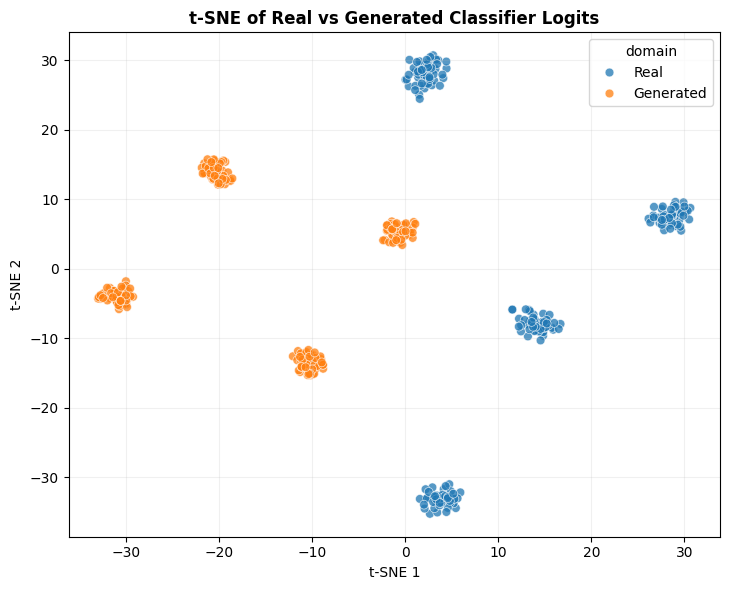

Final GAN analysis summary
--------------------------------------------------------------------------------
Selected classes: Battery, Mobile, PCB, light bulbs
Best trial: cdgan_hinge_proj_z128_g96_d96
Classifier target accuracy: 0.000
Mean target probability: 0.028
Frechet logit distance: 58.756
Diversity score: 2.510
Interpretation: lower Frechet distance is better; higher classifier agreement, confidence, and diversity are better.


In [29]:
real_sample = real_logits[: min(220, len(real_logits))]
fake_sample = best_payload['fake_logits'][: min(220, len(best_payload['fake_logits']))]
tsne_input = np.vstack([real_sample, fake_sample])
tsne_domain = np.array(['Real'] * len(real_sample) + ['Generated'] * len(fake_sample))

tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, max(5, len(tsne_input) // 12)), init='pca', learning_rate='auto')
tsne_points = tsne.fit_transform(tsne_input)
tsne_frame = pd.DataFrame({'x': tsne_points[:, 0], 'y': tsne_points[:, 1], 'domain': tsne_domain})

plt.figure(figsize=(7.4, 6.0))
sns.scatterplot(data=tsne_frame, x='x', y='y', hue='domain', alpha=0.75, s=40)
plt.title('t-SNE of Real vs Generated Classifier Logits', fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(alpha=0.18)
plt.tight_layout()
save_current_figure(GRAPHS_DIR / 'gan_real_vs_generated_tsne.png')
plt.show()

print('Final GAN analysis summary')
print('-' * 80)
print(f"Selected classes: {', '.join(selected_classes)}")
print(f"Best trial: {best_trial_name}")
print(f"Classifier target accuracy: {best_metrics['classifier_target_accuracy']:.3f}")
print(f"Mean target probability: {best_metrics['mean_target_probability']:.3f}")
print(f"Frechet logit distance: {best_metrics['frechet_logit_distance']:.3f}")
print(f"Diversity score: {best_metrics['diversity_score']:.3f}")
print('Interpretation: lower Frechet distance is better; higher classifier agreement, confidence, and diversity are better.')